## Sensitivity analysis

In [1]:
from approx_polyA_model_white_tails import PolyAModel_mean
import matplotlib.pyplot as plt

import xarray as xr
import pandas as pd
import numpy as np

# fixed parameter set:
P00 = 15
L_frag_kb = 0.1

P_max0 = 100.0
S_depth = 3.8e6

K_b0 = 15.85
n0 = 2.0

P_min0 = 10.0
k_d0 = 5.0
k_p0 = 1.0

genes = {"ENSDARG00000040266": {"name": "Sox19b", "P0":20.0},}

results_dict = {"s_deg" : {"range": [], "results": []},
                "n":  {"range": [],  "results": []},
                "K_b":  {"range": [],  "results": []},
                #"h_b":    {"range": [], "results": [],}, 
                "P_min":  {"range": [],  "results": []}, 
                "P_max": {"range": [],  "results": []},
                "P0": {"range": [],  "results": []},
                "k_d": {"range": [],  "results": []},
                "k_p": {"range": [],  "results": []},}

results_dict["n"]["range"] = [1, 2, 4, 6, 10] #np.linspace(1.0, 10.0, 6)
results_dict["s_deg"]["range"] = np.linspace(0.10, 1.0, 7)
results_dict["K_b"]["range"] =   [10., 15.85, 20., 25., 30.]  #np.linspace(10.0, 30.0, 5)
results_dict["P_min"]["range"]   = np.linspace(5, 30, 6)
results_dict["P_max"]["range"]   = np.linspace(60, 160, 6)
results_dict["P0"]["range"] = np.linspace(10.0, 30.0, 5)
results_dict["k_d"]["range"] = np.linspace(1.0, 6.0, 6)
#results_dict["k_p"]["range"] = np.linspace(5, 35, 7)
results_dict["k_p"]["range"] = np.linspace(0.1, 2, 7)

## Effect of binding strength

c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\sympy2jax\sympy_module.py:290: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  has_extra_funcs: bool = eqx.static_field()
c:\Users\mgrho\polyA_model\approx_polyA_model_white_tails.py:380: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  data = xr.merge([obs, rep, p_obs])
c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\pymob\simulation.py:307: UserWarning: `sim.config.data_structure.TPM_biased = Datavariable(dimensions=['time'] min=44.43220000000001 max=611.3184 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dim

Scenario directory exists at 'c:\Users\mgrho\polyA_model\case_studies\PolyAModel_mean_approx_White_tails\scenarios\ENSDARG00000040266'.
MinMaxScaler(variable=TPM_biased, min=44.43220000000001, max=611.3184)
MinMaxScaler(variable=miRNA, min=0.0, max=0.9990243902439024)
MinMaxScaler(variable=P, min=31.1, max=38.0)
SF  0.5111
T0:  3063.1704605752298
<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    P        float64 8B 6.358
    H        float64 8B 0.0
{'k_p': 1.0, 'k_d': 5.0, 'P_max': 100.0, 'sigma_y': 0.1, 'P_min': 10.0}


c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\pymob\simulation.py:918: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  k:v for k, v in reference_data.dims.items()
<frozen _collections_abc>:861: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


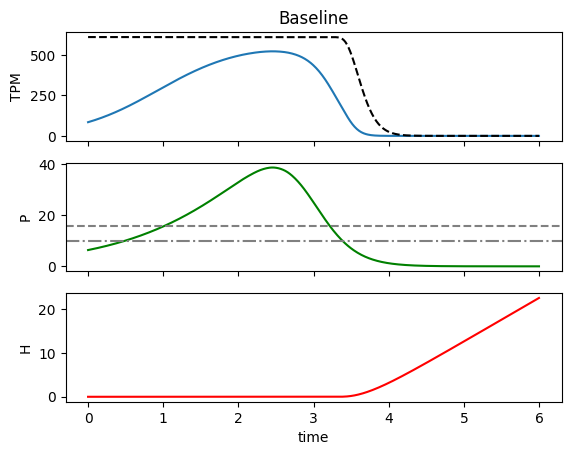

In [2]:
baseline = []
gene_id = "ENSDARG00000002912"
gene_id ="ENSDARG00000040266"

model = PolyAModel_mean(L_frag_kb = L_frag_kb,
                        K_b = K_b0,
                        P_min = P_min0,
                        P_max = P_max0,
                        S_depth = S_depth,
                        n = n0,
                        k_d = k_d0,
                        k_p = k_p0)

results, = model.simulate(gene_id, seed=1, eval=True, plot=False)
baseline.append([results.TPM_biased, results.TPM_true, results.P, results.H])
baseline

# plot baseline
fig, (ax0, ax1, ax2) = plt.subplots(3,1, sharex=True)
ax0.plot(baseline[0][0].time, baseline[0][0]) #bias
ax0.plot(baseline[0][1].time, baseline[0][1], "k", ls="--", ) # True
ax1.plot(baseline[0][2].time, baseline[0][2],"green") # P
ax1.axhline(P_min0, xmin=0, xmax=6, c="grey", ls="-.") # P
ax1.axhline(K_b0, xmin=0, xmax=6, c="grey", ls="--") # P

ax2.plot(baseline[0][3].time, baseline[0][3],"r") # H
ax0.set(ylabel="TPM", title=f"Baseline")
ax1.set(ylabel="P")
ax2.set(xlabel="time", ylabel="H")
#plt.savefig(f"figures/baseline_for_sensitivity_hsigmoid.png")
plt.savefig(f"figures/Sensitivity/baseline_for_sensitivity_hlinear.png")

In [3]:
# vary n / K_b
def param_variation(results_dict, param,):

    results_list = []

    for p in results_dict[param]["range"] :

        n = p if param == "n" else n0
        K_b = p if param == "K_b" else K_b0
        #s_deg = p if param == "s_deg" else s_deg0
        #h_b = p if param == "h_b" else h_b0
        P_min = p if param == "P_min" else P_min0
        P_max = p if param == "P_max" else P_max0
        P0 = p if param == "P0" else P00
        k_d = p if param == "k_d" else k_d0
        k_p = p if param == "k_p" else k_p0

        gene_id = "ENSDARG00000040266"

        model = PolyAModel_mean(
                                L_frag_kb = L_frag_kb,
                                K_b = K_b,
                                P_min = P_min,
                                P_max = P_max,
                                S_depth = S_depth,
                                n = n,
                                #s_deg = s_deg, 
                                k_d = k_d,
                                k_p = k_p)

        results, = model.simulate(gene_id, seed=1, eval=True, plot=False)
        results_list.append([results.TPM_biased, results.TPM_true, results.P, results.H])

    results_dict[param]["results"] = results_list
    
    return results_dict

In [4]:
## --- PLOT ---
from matplotlib import colormaps
import matplotlib.pyplot as plt


def plot_binding_sen(results_dict, param):
    
    means = []
    P = np.linspace(0, 50, 100)
    K_b = 20 
    fig, (ax2) = plt.subplots(1,1, figsize=(5, 4))

    colors = colormaps['turbo'].resampled(7)
    results_list = results_dict[param]["results"]

    for i, p in enumerate(results_dict[param]["range"]):

        n = p if param == "n" else n0
        K_b = p if param == "K_b" else K_b0

        #results = (baseline[0][0] - results_list[i][0]) / baseline[0][0] # diff to baseline
        results = (baseline[0][0] - results_list[i][0])  # diff to baseline

        f_binding = P**n / (K_b**n + P**n)

        means.append(results_list[i][0].mean()) ## mean TPM
        #ax1.plot(results.time, results, label=f"{p}", c=colors(i))
        ax2.plot(P, f_binding, label=f"{p}",  c=colors(i))
        
    results_dict[param]["means"] = means

    #ax1.set(xlabel="time", ylabel="diff. to baseline", title=f"Senstivity of {param} on "+"$TPM_{biased}$")
    ax2.set(xlabel="poly(A) tail length", ylabel="$f_b$", title="binding affinity $f_b$")
    #ax1.legend(loc =( 1.01, 0.2))
    ax2.legend(loc =( 1.01, 0.2), title=param,  frameon=False)
    plt.tight_layout()
    plt.savefig(f"figures/Sensitivity/sensitivity_{param}_on_fb.png")
    plt.show()

    return results_dict

def plot_degradation_sen(results_dict, param):
    
    means = []
    s_deg0 =1
    P = np.linspace(0, 50, 100)
    K_b = 20 
    fig, (ax2) = plt.subplots(1,1, figsize=(5, 4))

    colors = colormaps['turbo'].resampled(7)
    results_list = results_dict[param]["results"]

    for i, p in enumerate(results_dict[param]["range"]):

        s_deg = p if param == "s_deg" else s_deg0
        #h_b = p if param == "h_b" else h_b0
        P_min = p if param == "P_min" else P_min0

        #results = (baseline[0][0] - results_list[i][0]) / baseline[0][0] # diff to baseline - TPM bias
        #results = (baseline[0][1] - results_list[i][1]) / baseline[0][1] # diff to baseline - TPM true
        results = (baseline[0][1] - results_list[i][1])  # diff to baseline - TPM true

        #f_deg = 1 / (1 + np.exp(s_deg * (P - P_min)))
        f_deg = np.maximum(P_min - P, 0.0)

        means.append(results_list[i][1].mean().item()) ## mean TPM
        #ax1.plot(results.time, results, label=f"{p:.2f}", c=colors(i))
        ax2.plot(P, f_deg, label=f"{p:.2f}",  c=colors(i))
        
    results_dict[param]["means"] = means
    results_dict[param]["means_true"] = means

    #ax1.set(xlabel="time", ylabel="diff. to baseline", title=f"senstivity of {param} on TPM true")
    ax2.set(xlabel="poly(A) tail length", ylabel="$f_{deg}$", title="Degradation hazard")
    #ax1.legend(loc =( 1.01, 0.2))
    ax2.legend(loc =( 1.01, 0.2), title=param, frameon=False)

    plt.tight_layout()
    plt.savefig(f"figures/Sensitivity/sensitivity_{param}_on_h.png")
    plt.show()

    return results_dict


def plot_traj_sen(results_dict, param):
    
    means = []
    P = np.linspace(0, 50, 100)
    K_b = 20 
    fig, ax1 = plt.subplots(1,1, figsize=(8, 4))

    colors = colormaps['turbo'].resampled(7)
    results_list = results_dict[param]["results"]

    for i, p in enumerate(results_dict[param]["range"]):

        ax1.plot(results_list[i][0].time, results_list[i][0], label=f"{p:.2f}", c=colors(i))
        ax1.plot(results_list[i][1].time, results_list[i][1], c=colors(i), ls="--")
        
    results_dict[param]["means"] = means

    ax1.set(xlabel="time", ylabel="TPM", title=f"Effect of {param} on TPM prediction")
    ax2.set(xlabel="poly(A) tail length", ylabel="$f_{deg}$", title="Degradation hazard")
    ax1.legend(loc =( 1.01, 0.2),  title=param, frameon=False)
    plt.tight_layout()
    plt.savefig(f"figures/Sensitivity/sensitivity_{param}_traj.png")
    plt.show()

    return results_dict


def plot_traj_senP(results_dict, param):
    
    means = []
    P = np.linspace(0, 50, 100)
    K_b = 20 
    fig, ax1 = plt.subplots(1,1, figsize=(8, 4))

    colors = colormaps['turbo'].resampled(7)
    results_list = results_dict[param]["results"]

    for i, p in enumerate(results_dict[param]["range"]):

        ax1.plot(results_list[i][2].time, results_list[i][2], label=f"{p:.2f}", c=colors(i))
        #ax1.plot(results_list[i][1].time, results_list[i][1], c=colors(i), ls="--")
        
    results_dict[param]["means"] = means

    ax1.set(xlabel="time", ylabel="poly(A) tail length", title=f"Effect of {param} on poly(A) tail length")
    #ax2.set(xlabel="PolyA tail length", ylabel="f_deg", title="degradation hazard")
    ax1.legend(loc =( 1.01, 0.2),  title=param,  frameon=False)
    plt.tight_layout()
    plt.savefig(f"figures/Sensitivity/sensitivity_{param}_traj_P.png")
    plt.show()

    return results_dict

In [8]:
# calculate results
#results_dict = param_variation(results_dict, "s_deg", )
results_dict = param_variation(results_dict, "n", )
results_dict = param_variation(results_dict, "K_b", )
results_dict = param_variation(results_dict, "P_min", )
results_dict = param_variation(results_dict, "P_max", )
results_dict = param_variation(results_dict, "k_d", )
results_dict = param_variation(results_dict, "k_p", )

Scenario directory exists at 'c:\Users\mgrho\polyA_model\case_studies\PolyAModel_mean_approx_White_tails\scenarios\ENSDARG00000040266'.
MinMaxScaler(variable=TPM_biased, min=44.43220000000001, max=611.3184)
MinMaxScaler(variable=miRNA, min=0.0, max=0.9990243902439024)
MinMaxScaler(variable=P, min=31.1, max=38.0)


c:\Users\mgrho\polyA_model\approx_polyA_model_white_tails.py:380: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  data = xr.merge([obs, rep, p_obs])
c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\pymob\simulation.py:307: UserWarning: `sim.config.data_structure.TPM_biased = Datavariable(dimensions=['time'] min=44.43220000000001 max=611.3184 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.TPM_biased = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\pymob\simulation.py:307: Us

SF  0.5111
T0:  3063.1704605752298
<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    P        float64 8B 2.551
    H        float64 8B 0.0
{'k_p': 1.0, 'k_d': 5.0, 'P_max': 100.0, 'sigma_y': 0.1, 'P_min': 10.0}


c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\pymob\simulation.py:918: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  k:v for k, v in reference_data.dims.items()
<frozen _collections_abc>:861: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


Scenario directory exists at 'c:\Users\mgrho\polyA_model\case_studies\PolyAModel_mean_approx_White_tails\scenarios\ENSDARG00000040266'.
MinMaxScaler(variable=TPM_biased, min=44.43220000000001, max=611.3184)
MinMaxScaler(variable=miRNA, min=0.0, max=0.9990243902439024)
MinMaxScaler(variable=P, min=31.1, max=38.0)


...

c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\pymob\simulation.py:918: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  k:v for k, v in reference_data.dims.items()
<frozen _collections_abc>:861: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


Scenario directory exists at 'c:\Users\mgrho\polyA_model\case_studies\PolyAModel_mean_approx_White_tails\scenarios\ENSDARG00000040266'.
MinMaxScaler(variable=TPM_biased, min=44.43220000000001, max=611.3184)
MinMaxScaler(variable=miRNA, min=0.0, max=0.9990243902439024)
MinMaxScaler(variable=P, min=31.1, max=38.0)


c:\Users\mgrho\polyA_model\approx_polyA_model_white_tails.py:380: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  data = xr.merge([obs, rep, p_obs])
c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\pymob\simulation.py:307: UserWarning: `sim.config.data_structure.TPM_biased = Datavariable(dimensions=['time'] min=44.43220000000001 max=611.3184 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.TPM_biased = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\pymob\simulation.py:307: Us

SF  0.5111
T0:  3063.1704605752298
<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    P        float64 8B 6.358
    H        float64 8B 0.0
{'k_p': array(2.), 'k_d': 5.0, 'P_max': 100.0, 'sigma_y': 0.1, 'P_min': 10.0}


c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\pymob\simulation.py:918: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  k:v for k, v in reference_data.dims.items()
<frozen _collections_abc>:861: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


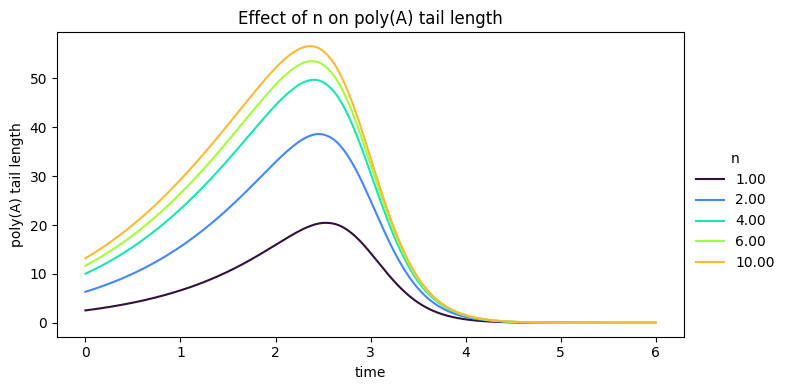

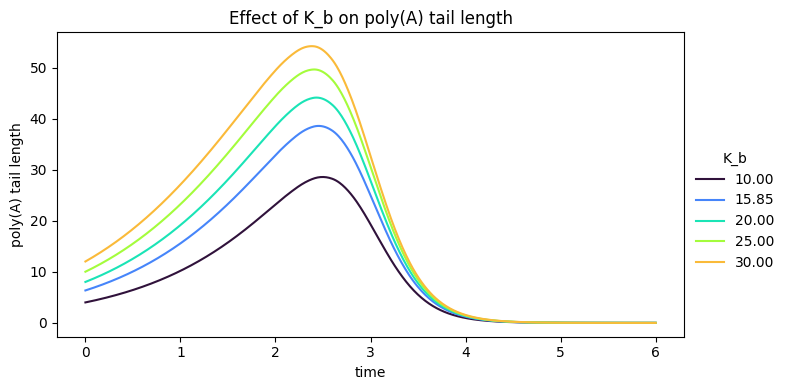

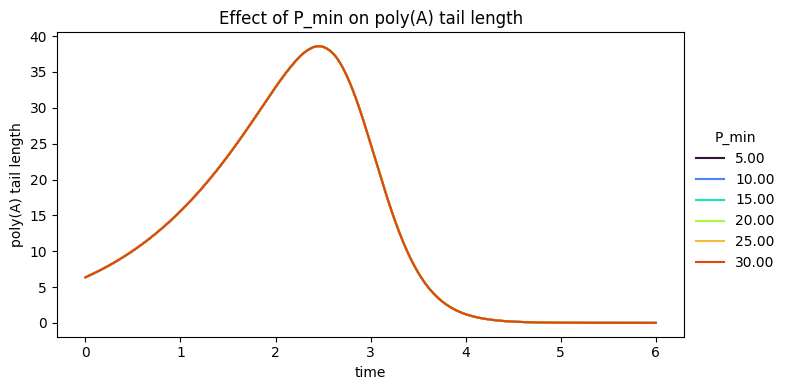

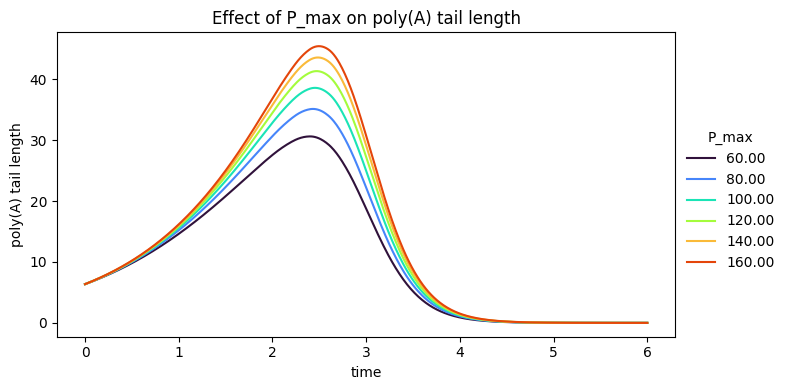

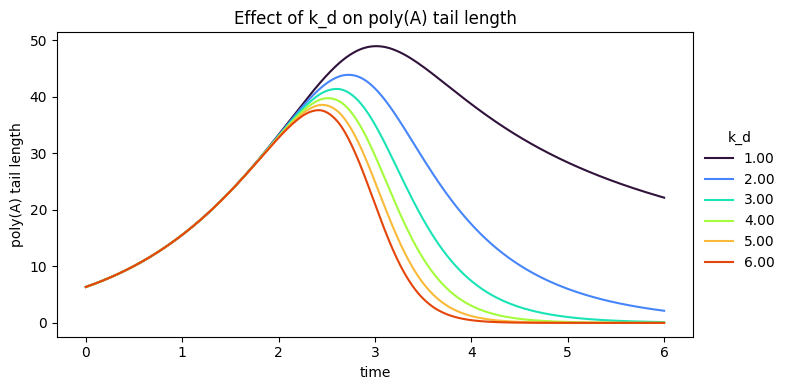

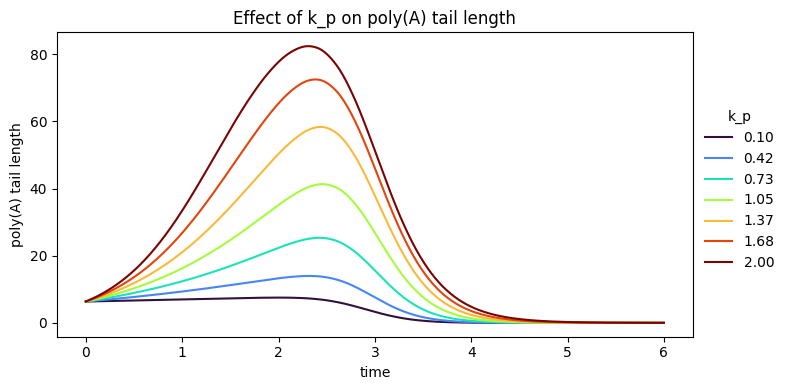

In [9]:
# plots model results -> f_deg Threshold version
results_dict = plot_traj_senP(results_dict, "n", )
results_dict = plot_traj_senP(results_dict, "K_b", )
results_dict = plot_traj_senP(results_dict, "P_min", )
results_dict = plot_traj_senP(results_dict, "P_max", )
#results_dict = plot_traj_senP(results_dict, "P0", )
results_dict = plot_traj_senP(results_dict, "k_d", )
results_dict = plot_traj_senP(results_dict, "k_p", )

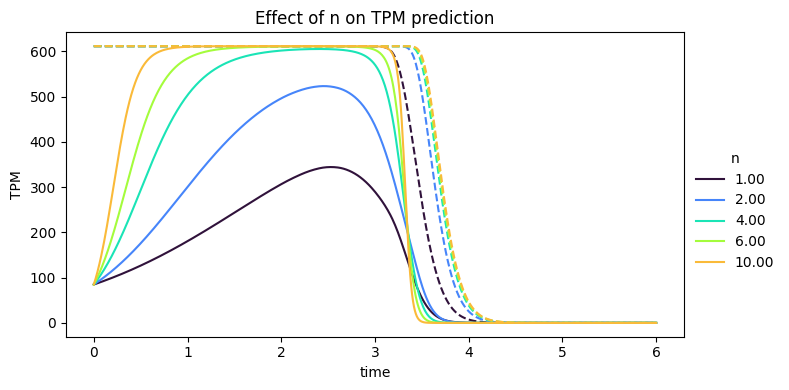

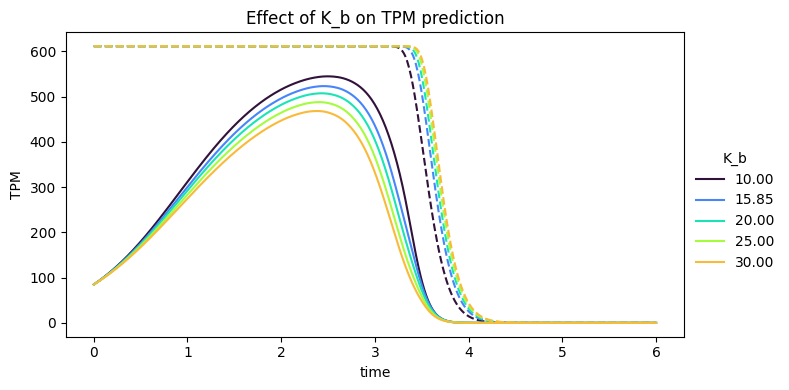

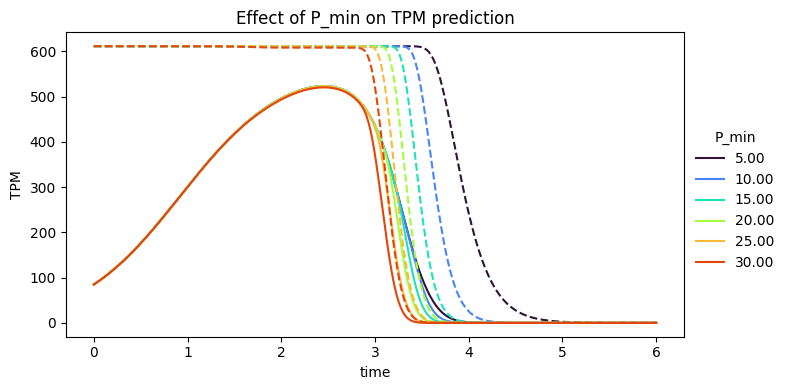

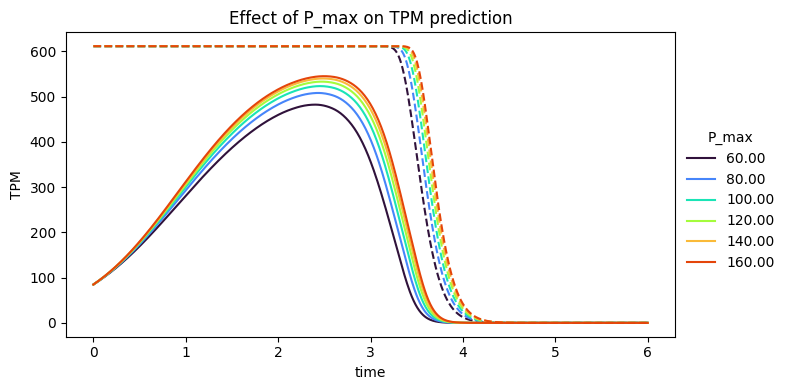

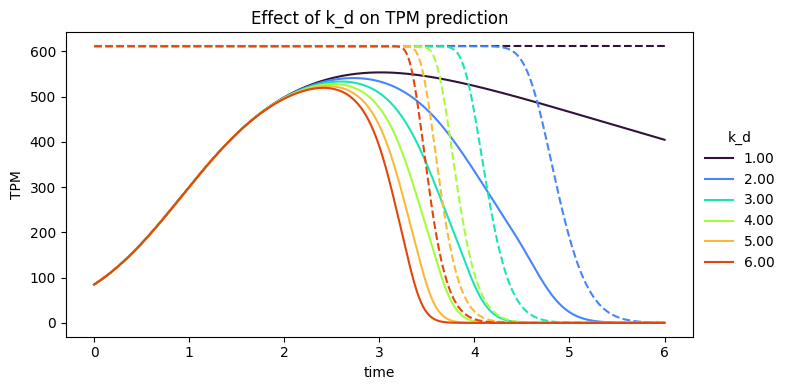

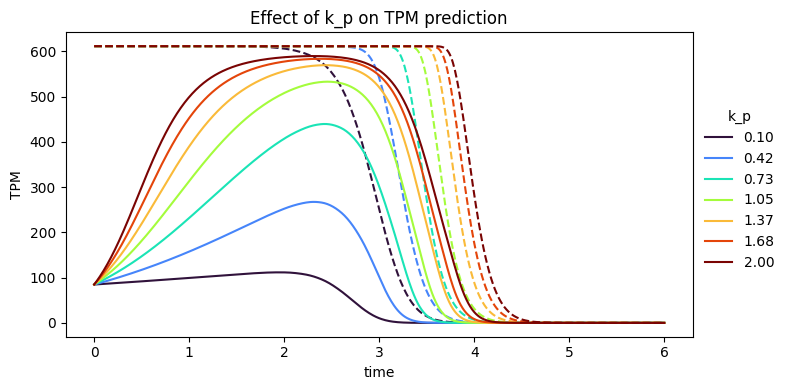

In [10]:
# plots model results -> f_deg Threshold version
results_dict = plot_traj_sen(results_dict, "n", )
results_dict = plot_traj_sen(results_dict, "K_b", )
results_dict = plot_traj_sen(results_dict, "P_min", )
results_dict = plot_traj_sen(results_dict, "P_max", )
#results_dict = plot_traj_sen(results_dict, "P0", )
results_dict = plot_traj_sen(results_dict, "k_d", )
results_dict = plot_traj_sen(results_dict, "k_p", )

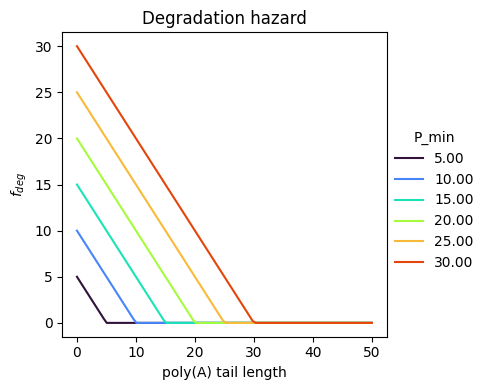

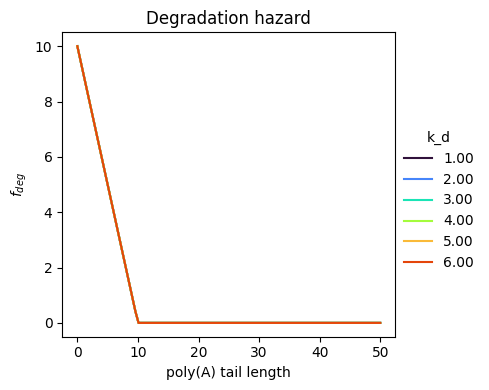

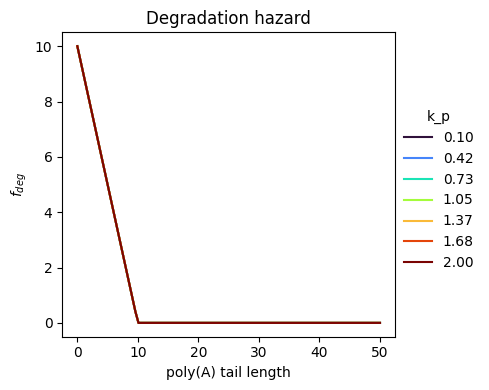

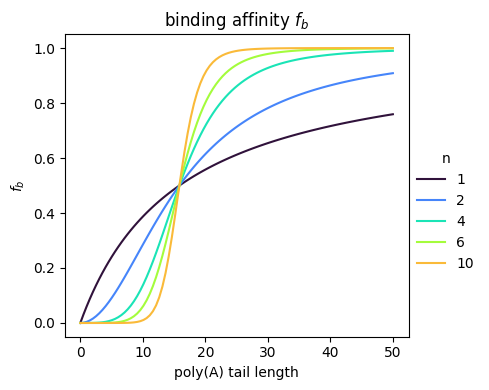

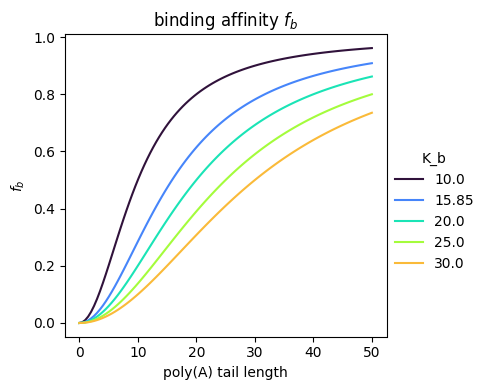

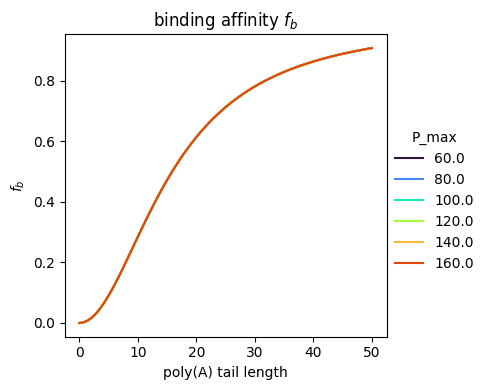

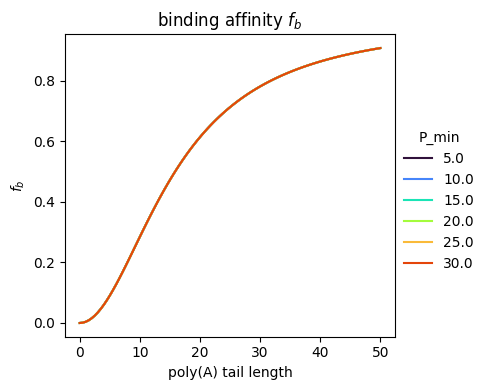

In [11]:
results_dict = plot_degradation_sen(results_dict, "P_min",  )
#results_dict = plot_degradation_sen(results_dict, "s_deg", )
#results_dict = plot_degradation_sen(results_dict, "h_b",  )

results_dict = plot_degradation_sen(results_dict, "k_d", )
results_dict = plot_degradation_sen(results_dict, "k_p", )

results_dict = plot_binding_sen(results_dict, "n",  )
results_dict = plot_binding_sen(results_dict, "K_b",  )
results_dict = plot_binding_sen(results_dict, "P_max",  )
results_dict = plot_binding_sen(results_dict, "P_min",  )
#results_dict = plot_binding_sen(results_dict, "P0",  )

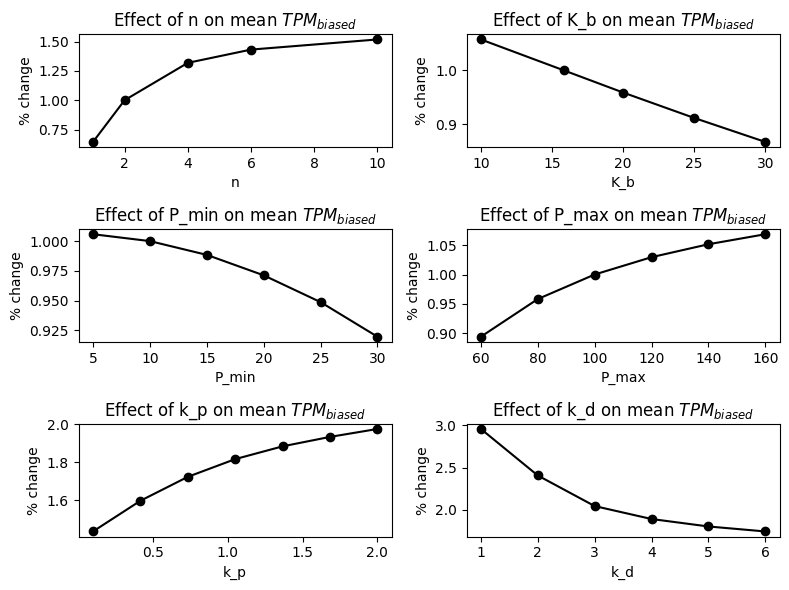

In [12]:
par = ['n', 'K_b', 'P_min', 'P_max', "k_p", "k_d"]
baseline_mean = baseline[0][0].mean().item()

# ----- 
#n = int(len(results_dict.keys()) / 2  + 1)
n = len(par) / 2
fig, ax = plt.subplots(3, 2, figsize=(8, 6), sharey=False)
ax = ax.flatten()
#for i, param in enumerate(results_dict.keys()):
for i, param in enumerate(par):
    try:
        x = []
        for n in results_dict[param]["means"]:
            x.append(n / baseline_mean)
        ax[i].plot(results_dict[param]["range"], x, "o-", label=param, c="k")
        ax[i].set(xlabel=param, ylabel="% change", title=f"Effect of {param} on mean "+"$TPM_{biased}$")
        #ax[i].plot(results_dict[param]["range"], results_dict[param]["means"], "o-", label=param, c="k")
    except:
        continue
    
plt.tight_layout()
plt.savefig(f"figures/Sensitivity/sensitivity_values_on_TPM_bias")
plt.show()